## Splitting participants to train/test sets
### Self-assessment data

In [16]:
import os
import os.path

from downstream_tasks.utils.study_dates import get_study_dates
from downstream_tasks.utils.assessments_utils import get_participant_assessments

# TODO: set the path
DATA_PATH = ""

i_participant_assessments = {}
for iteration in range(1, 8):
    i_participant_assessments[iteration] = {}
    i_path = f"{DATA_PATH}/i_0{iteration}/zip_participants_merged"
    p_list = [x for x in os.listdir(i_path) if '.' not in x or ' ' not in x]
    i_study_dates = get_study_dates(f"i_0{iteration}")

    for participant in p_list:
        p_path = f"{i_path}/{participant}"
        emotion_a, morning_a, evening_a = get_participant_assessments(p_path)
        i_participant_assessments[iteration][participant] = {
            "emotion": emotion_a,
            "morning": morning_a,
            "evening": evening_a,
        }

In [18]:
from downstream_tasks.utils.constants import TIMESTAMP_FORMAT_ASSESSMENTS
from datetime import datetime

VERBOSE = False

def nice_percent(value):
    return round(value, 2) * 100

# iteration_0i_<UID> -> {emotion: <filled_num>, morning: <filled_num>, evening: <filled_num>}
p_ranking = {}
for i, i_participants in i_participant_assessments.items():
    i_start, i_end = get_study_dates(i)
    if VERBOSE:
        print(f"Iteration {i}, Participants: {len(i_participants)}")
        print("i_start, i_end: ", i_start, i_end)
    i_percents_filled_list = {x: [] for x in ["emotion", "morning", "evening"]}
    
    for participant, p_assessments in i_participants.items():
        p_label = f"iteration_0{i}_{participant}"
        p_ranking[p_label] = {}
        
        for a_type in ["emotion", "morning", "evening"]:
            p_in_ranges = [ x for x in p_assessments[a_type].values() if 
               i_start <= datetime.strptime(x["createdTimestamp"], TIMESTAMP_FORMAT_ASSESSMENTS).date() and
               datetime.strptime(x["createdTimestamp"], TIMESTAMP_FORMAT_ASSESSMENTS).date() <= i_end
            ]
            
            p_filled = [x for x in p_in_ranges if x["status"] == "FILLED"]
            p_ranking[p_label][a_type] = len(p_filled)

            if a_type == "emotion":
                p_ranking[p_label][f"{a_type}_%"] = nice_percent(len(p_filled)/len(p_in_ranges))
            
            if VERBOSE:
                print(f"{a_type} assessments")
                print("Filled num: ", len(p_filled))
                print(f"{nice_percent(len(p_filled)/len(p_in_ranges))}%")
                print()

            if len(p_in_ranges) == 0:
                print(f"0 assessments in len(p_in_ranges), for {participant} in {i}")
                continue

            if VERBOSE and len(p_filled) == len(p_in_ranges):
                print(a_type)
                print(i, participant, len(p_in_ranges), len(p_in_ranges))    

In [19]:
import pandas as pd

p_ranking_df = pd.DataFrame(p_ranking).T
p_ranking_df_sorted = p_ranking_df.sort_values(['morning', 'evening', 'emotion', 'emotion_%',], ascending=[False, False, False, False])
p_ranking_df_sorted

,emotion,emotion_%,morning,evening
iteration_03_D19yFwUGNJhbSOEW2duM0ui6YII3,167.0,98.0,28.0,28.0
iteration_03_rPBwrd04gBQbKtYRDrhJYLlRFe33,166.0,99.0,28.0,28.0
iteration_03_ijiZnSsZ38VzAMdwSeqEvRSP9Mn2,155.0,92.0,28.0,28.0
iteration_04_FjAOqvFmWUdm2tDfk7PUXPf33CH3,149.0,91.0,28.0,28.0
iteration_04_s3IpVEvxi8U17uJZXQHDGQV4SiF2,144.0,86.0,28.0,28.0
...,...,...,...,...
iteration_03_h49eN1RfJycu9y4xBDZFt168mkg1,35.0,32.0,16.0,14.0
iteration_01_Fjnjwo9mLvYbbduDonQ1HLSDvEs2,29.0,22.0,15.0,21.0
iteration_06_iCKCpJVxy8OKMpHg7wtuMyztxBm2,59.0,67.0,14.0,21.0
iteration_07_7YdosNk7y8h4yLDqJq9dWomVqbe2,14.0,19.0,13.0,17.0


### Demography data

In [9]:
import pandas as pd

# TODO: set the path
DATA_PATH = ""
demography_df = pd.read_csv(f"{DATA_PATH}/demography/demography-new.csv", sep='\t', index_col=0)
# print("demography_df cols: ", demography_df.columns)

demography_df = demography_df[["UID","iteration", "Jak określasz swoją płeć?", "Jaki jest Twój wiek (w latach, liczbą)?"]]
demography_df["ID"] = demography_df.apply(lambda row: f"iteration_0{int(row.iteration)}_{row.UID}", axis=1)
demography_df = demography_df.set_index("ID")
demography_df = demography_df.rename(columns={"Jak określasz swoją płeć?": "Gender", "Jaki jest Twój wiek (w latach, liczbą)?": "Age"})
demography_df = demography_df.drop(columns=['UID', 'iteration'])

# demography_df[["Gender", "Age"]].hist(bins=35)
demography_df

,Gender,Age
ID,,
iteration_01_Fjnjwo9mLvYbbduDonQ1HLSDvEs2,Mężczyzna,21
iteration_01_WfmfqzH5Osc21zu8ad4copEoPQt2,Mężczyzna,22
iteration_01_htIsC7hQeVasSREKTIF9pcBPCEn2,Kobieta,20
iteration_01_1Apsk9nXvtMpGECm9iiF6qkFmUJ2,Mężczyzna,20
iteration_01_GnG62bs0maeT2nq8kE6XcW9yJRs2,Mężczyzna,19
...,...,...
iteration_07_7YdosNk7y8h4yLDqJq9dWomVqbe2,Mężczyzna,29
iteration_07_YeyRZ4NR7sOxUm3rrujk2JZ3hA93,Kobieta,23
iteration_07_rf3XDediG6heKJOwfTNmBsr4mzo1,Kobieta,23


### Splitting data providing a similar distribution for the folds.

Age and gender are treated as labels in the multi-label problem using [IterativeStratification from skmultilearn](http://scikit.ml/api/skmultilearn.model_selection.iterative_stratification.html)

In [20]:
import numpy as np
from skmultilearn.model_selection import IterativeStratification

combined_df = pd.concat([p_ranking_df_sorted, demography_df], axis=1)
combined_df = combined_df.replace({
    "Kobieta": 0, "Mężczyzna": 1,
    "queer": 2, "Wolę nie mówić": 3,
})

# restructuring the data
dataset = [(idx, {key: val for key, val in data.items()}) for idx, data in combined_df.T.to_dict().items()]

X, y = [], []
for idx, row in enumerate(dataset):
    values = row[1]
    tmp = [row[0]] + [val for key, val in values.items() if key not in ["Gender", "Age"]]
    X.append(tmp)
    y.append([val for key, val in values.items() if key in ["Gender", "Age"]])

y = np.array(y)
print(X[0], y[0])

['iteration_03_D19yFwUGNJhbSOEW2duM0ui6YII3', 167.0, 98.0, 28.0, 28.0] [ 0. 25.]


C:\Users\Joann\AppData\Local\Temp\ipykernel_12600\3841667878.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  combined_df = combined_df.replace({


In [25]:
k_fold = IterativeStratification(n_splits=7, order=1, sample_distribution_per_fold=None)

result, split_num = {x[0]: None for x in X}, 0
for train, test in k_fold.split(X, y):
    # print(len(train))
    # print(len(test))

    for idx in test:
        result[X[idx][0]] = split_num
    split_num += 1
    
# save the folds
# TODO: set the path
# folds_path = "./folds.csv"
# result_df = pd.DataFrame.from_dict(result, orient="index", columns=["Fold"])
# result_df.to_csv(folds_path, header=False)

## Check assessments compliance between folds

In [27]:
# TODO: set the path
folds_path = "./folds.csv"
result_df = pd.read_csv(folds_path, header=None, index_col=0, names=["Fold"])
result_combined_df = pd.concat([result_df, p_ranking_df_sorted, demography_df], axis=1)

# todo add boxplots
for fold in range(7):
    f_data = result_combined_df[result_combined_df.Fold == fold][["emotion", "emotion_%", "morning", "evening"]]
    print(f"Fold {fold} -> Participants: {len(f_data)}")
    f_description = f_data.describe()
    
    for a_type in ["emotion", "morning", "evening",]: # "daily", "all_types"]:
        print(a_type)
        tmp = f_description[a_type].to_dict()
        print(f"{round(tmp['mean'], 2)} +/- {round(tmp['std'], 2)}")
        print(f"{tmp['min']} --- {tmp['max']}", '\n')

Fold 0 -> Participants: 24
emotion
107.96 +/- 34.67
30.0 --- 197.0 

morning
24.92 +/- 3.05
17.0 --- 28.0 

evening
24.04 +/- 4.3
13.0 --- 28.0 

Fold 1 -> Participants: 24
emotion
106.33 +/- 34.88
46.0 --- 161.0 

morning
24.75 +/- 3.44
14.0 --- 28.0 

evening
24.62 +/- 3.92
12.0 --- 28.0 

Fold 2 -> Participants: 24
emotion
116.33 +/- 31.8
38.0 --- 155.0 

morning
24.58 +/- 3.88
11.0 --- 28.0 

evening
24.58 +/- 5.72
3.0 --- 28.0 

Fold 3 -> Participants: 24
emotion
111.67 +/- 36.92
24.0 --- 167.0 

morning
24.83 +/- 3.21
16.0 --- 28.0 

evening
25.04 +/- 3.63
13.0 --- 28.0 

Fold 4 -> Participants: 24
emotion
112.33 +/- 32.79
35.0 --- 166.0 

morning
24.79 +/- 3.2
16.0 --- 28.0 

evening
24.12 +/- 5.75
7.0 --- 28.0 

Fold 5 -> Participants: 23
emotion
112.52 +/- 42.28
29.0 --- 243.0 

morning
24.78 +/- 3.19
15.0 --- 28.0 

evening
25.09 +/- 2.76
19.0 --- 28.0 

Fold 6 -> Participants: 24
emotion
113.04 +/- 30.06
14.0 --- 157.0 

morning
24.79 +/- 3.56
13.0 --- 28.0 

evening
24.75 +

## Manually swapping participants to 0 fold (test set) keeping similar demography distribution between the folds

In [ ]:
result_combined_df_s = result_combined_df.sort_values(['Fold', 'Gender', 'Age', 'morning', 'evening', 'emotion'],
                                                      ascending=[True, True, True, True, True, True])
test_df = result_combined_df_s[result_combined_df_s.Fold == 0][['Gender', 'Age', 'morning', 'evening', 'emotion']]
print("Fold 0 ~ test set")
# test_df

### Read the data, if continuing swapping

In [5]:
import pandas as pd

# TODO: set the path
folds_swapped_path = "./folds_swapped.csv"
result_combined_df_s = pd.read_csv(folds_swapped_path, header=None, index_col=0, names=["Fold"])
result_combined_df_s

,Fold
iteration_06_RydY89HJlyLzeNOrmcjn1ub6j6g1,0
iteration_03_XfuetknJVnQ1hZcBGNlrfeGB1823,0
iteration_01_1x6a3F7pIzd7B7BdZePh7Z0WC4A3,0
iteration_07_4uF8jaUO6nVOs6RPovkIwGw53qD2,0
iteration_06_bymVumJaGZaiLvw8xolKfE6L6Cp1,0
...,...
iteration_05_ni15qAL6jKbjmg7EfmURuzml9mp1,6
iteration_03_yLMtxaV799N9rVWUyYnOWqk0oj43,6
iteration_05_QxsTCw8t2VdlluDACws52AlPIDF3,6
iteration_02_PsIFnyVpOuZFP6Qrk7QQVwuJoqy1,6


In [20]:
if 'Age' not in result_combined_df_s.columns:
    if 'Fold' in demography_df.columns:
        demography_df = demography_df.drop(columns=['Fold'])
    result_combined_df_s = pd.concat([result_combined_df_s, demography_df], axis=1)
if 'morning' not in result_combined_df_s.columns:
    if 'Fold' in p_ranking_df_sorted.columns:
        p_ranking_df_sorted = p_ranking_df_sorted.drop(columns=['Fold'])
    result_combined_df_s = pd.concat([result_combined_df_s, p_ranking_df_sorted], axis=1)

# choose participant to swap and see the properties
p_to_swap = result_combined_df_s.loc["iteration_06_1F9p9TOfy7dvEUMj2x1Yj6SFn7C3"]
print(p_to_swap, '\n')

# print(result_combined_df_s[result_combined_df_s.Fold == fold][['Gender', 'Age', 'morning', 'evening', 'emotion']].Gender.value_counts())

# find "better" participants in other folds
age_range = 3
for fold in range(1, 7):
    print("Fold ", fold)
    current_df = result_combined_df_s[result_combined_df_s.Fold == fold][['Gender', 'Age', 'morning', 'evening', 'emotion']]
    # print(current_df.Gender.value_counts())
    print(current_df[(current_df.Gender == p_to_swap.Gender)
          & (p_to_swap.Age - age_range <= current_df.Age)  & (current_df.Age <= p_to_swap.Age + age_range)
          & (current_df.morning >= p_to_swap.morning) & (current_df.evening >= p_to_swap.evening)])

# 1st swapping
# from_test_list = ["iteration_06_XPdODMBWjjgH0WFDjsRYPVRPo9R2","iteration_07_XbRTIcjVilRxRJqHMTy34WCNsyy1","iteration_07_UjLSkmRg7VafpElMa3GYvHqgsJt2",
#                  "iteration_03_bOt6VeKouzUhaM8BlW97Y1tVUyE3","iteration_03_ddUEMt9WEcWY7HdHYGj3tRLuCIn1","iteration_03_1WXmlPK6mfVkqYXlsNJvxKkw37C3",
#                  "iteration_01_Ai5Bvz3hWPf71Z6fpDihHcLpCBy1","iteration_06_sIIYD0AgTAYZB8gPiR6cJigHxvC3","iteration_01_1Apsk9nXvtMpGECm9iiF6qkFmUJ2",
#                  "iteration_01_HIybz0C6trhOntNKNJTWhbU6fDy2","iteration_04_esXo4bAtdtMgDsiIS0zYbJC25p72","iteration_04_9OC6vfauX1bCwLiWGL1j9ImBZQy1",
#                  "iteration_03_ehbAaiTNQZRKTuCLCdCYZfoTqnb2",]
# to_test_list = ["iteration_03_nyhUXXi0IZXNxznwoDbabCwvHF53","iteration_03_rPBwrd04gBQbKtYRDrhJYLlRFe33","iteration_05_6SbXNCMDl3SyB97ZG0eQEnH5nI82",
#                 "iteration_05_6SbXNCMDl3SyB97ZG0eQEnH5nI82","iteration_05_MpUE7D05ybS4objMMB3mwPa2kPC3","iteration_04_2VaupA1XhdeElSqKXSxzGQljhT02",
#                 "iteration_02_pmsBIM9OSvRNH9NEn4eSoOEx4b73","iteration_06_LWcSrXZFVZOInPb8jlIjEZSCkdv1","iteration_07_CrnkUjRAp4VIZfrmcjSATt8RuKl1",
#                 "iteration_01_yPxyh96xjGflGsDmShrpBXckBks1","iteration_01_8w78a4X34RPmPpxxL0vncyDPXvt2","iteration_04_grVJgrgv4IX672aWnJr9a4ACfFr2",
#                 "iteration_06_WyWnCG4vTKeh2YF0UEtBpzGUcDi1",]

# 2nd swapping
# not_swaped = [
#     "iteration_06_1F9p9TOfy7dvEUMj2x1Yj6SFn7C3",  # 28/28/93
#     "iteration_05_2k9wwZkwkKaaH8cYrbgsCSGiJ3j2",  # 28/18/72
#     "iteration_05_sEEZ0fN2hVcDWjR1o5a68hA6wXK2",  # 27/28/119
#     "iteration_06_RydY89HJlyLzeNOrmcjn1ub6j6g1",  # 28/28/141
#     "iteration_06_Qnk1VccJE6hSPQDMi1bEjM1OK8j1",  # 26/27/98 
#     "iteration_03_unrr21ZT7dbneHvYVTMXS0xCJQW2",  # 26/27/134
#     "iteration_05_VVXO0jNUmpePYX9onB1HRIVMIuz1",  # 24/23/89
#     "iteration_03_XfuetknJVnQ1hZcBGNlrfeGB1823",  # 28/26/108
#     "iteration_05_m1TwAOaR1ibKu2Zy6O9xB845HuK2",  # 27/28/104
#     "iteration_01_1x6a3F7pIzd7B7BdZePh7Z0WC4A3",  # 28/27/197
#     "iteration_01_c6CPShm7qaeixkyFiQun8UU9PnX2",  # 23//27/119
# ]

# from_test_list = [
    # "iteration_05_2k9wwZkwkKaaH8cYrbgsCSGiJ3j2","iteration_03_unrr21ZT7dbneHvYVTMXS0xCJQW2","iteration_05_VVXO0jNUmpePYX9onB1HRIVMIuz1",
#                  "iteration_05_m1TwAOaR1ibKu2Zy6O9xB845HuK2","iteration_05_sEEZ0fN2hVcDWjR1o5a68hA6wXK2","iteration_01_c6CPShm7qaeixkyFiQun8UU9PnX2",
#                  "iteration_06_Qnk1VccJE6hSPQDMi1bEjM1OK8j1",
#                  "iteration_01_yPxyh96xjGflGsDmShrpBXckBks1", "iteration_03_bOt6VeKouzUhaM8BlW97Y1tVUyE3",
#                  "iteration_01_8w78a4X34RPmPpxxL0vncyDPXvt2",
#                   "iteration_06_1F9p9TOfy7dvEUMj2x1Yj6SFn7C3"
#                  ]
# to_test_list = [
    # "iteration_06_ou9yFAPtAzV0mtnuquyflipf5iQ2","iteration_02_9lsiyjS1FrXNnl3tC9H96zRDQUp1","iteration_05_6t6TTSYMybZDt2zbxLCMQvyLFdm2",
#                 "iteration_04_s3IpVEvxi8U17uJZXQHDGQV4SiF2","iteration_07_lxDA1xS7vOe0BpLCtFzDIYiGGZ52","iteration_06_ibWYuw58sJQjJ7D1MkfRwla4sri1",
#                 "iteration_06_bymVumJaGZaiLvw8xolKfE6L6Cp1",
#                "iteration_03_UxG1iktUAoPonFULajPCuDfXkpQ2", "iteration_06_NlwnRZ1tSTXnPa0tBhbgmeq51TR2",
#                "iteration_07_4uF8jaUO6nVOs6RPovkIwGw53qD2",
               #  "iteration_03_D19yFwUGNJhbSOEW2duM0ui6YII3"
               # ]

# print('\n', "len(not_swaped), len(from_test_list):", len(not_swaped), len(from_test_list), '\n')
print()
# swap fold num for participants in from_test_list and to_test_list
# for from_test, to_test in zip(from_test_list, to_test_list):
#     if from_test == "" or to_test == "":
#         continue
        
#     new_fold = result_combined_df_s.loc[to_test].Fold
#     if new_fold == 0:
#         continue
#     print(new_fold)
#     result_combined_df_s.at[from_test, "Fold"] = new_fold
#     result_combined_df_s.at[to_test, "Fold"] = 0

print(result_combined_df_s[result_combined_df_s.Fold == 0])
folds_swapped = result_combined_df_s[["Fold"]]
folds_swapped = folds_swapped.sort_values(['Fold'], ascending=[True])

# TODO: set the path
folds_swapped_path = "./folds_swapped.csv"
folds_swapped.to_csv(folds_swapped_path, header=False)

Fold               3
Gender       Kobieta
Age               23
emotion         93.0
emotion_%       65.0
morning         28.0
evening         28.0
Name: iteration_06_1F9p9TOfy7dvEUMj2x1Yj6SFn7C3, dtype: object 

Fold  1
Empty DataFrame
Columns: [Gender, Age, morning, evening, emotion]
Index: []
Fold  2
Empty DataFrame
Columns: [Gender, Age, morning, evening, emotion]
Index: []
Fold  3
                                            Gender  Age  morning  evening  \
iteration_06_1F9p9TOfy7dvEUMj2x1Yj6SFn7C3  Kobieta   23     28.0     28.0   

                                           emotion  
iteration_06_1F9p9TOfy7dvEUMj2x1Yj6SFn7C3     93.0  
Fold  4
Empty DataFrame
Columns: [Gender, Age, morning, evening, emotion]
Index: []
Fold  5
Empty DataFrame
Columns: [Gender, Age, morning, evening, emotion]
Index: []
Fold  6
Empty DataFrame
Columns: [Gender, Age, morning, evening, emotion]
Index: []

                                           Fold     Gender  Age  emotion  \
iteration_06_RydY89HJl

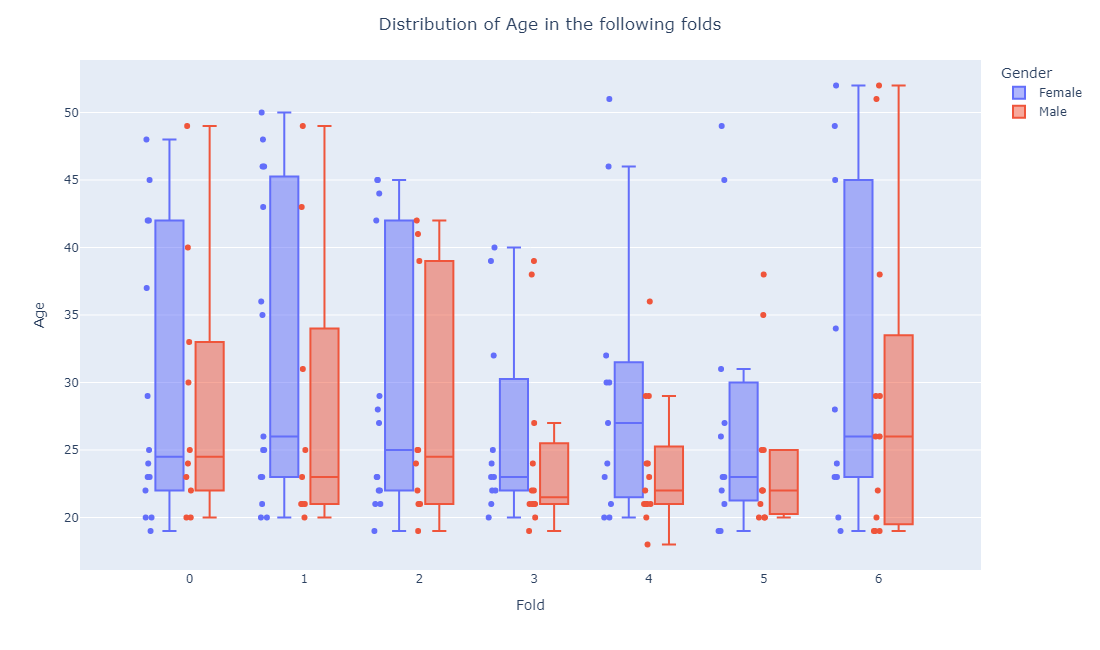

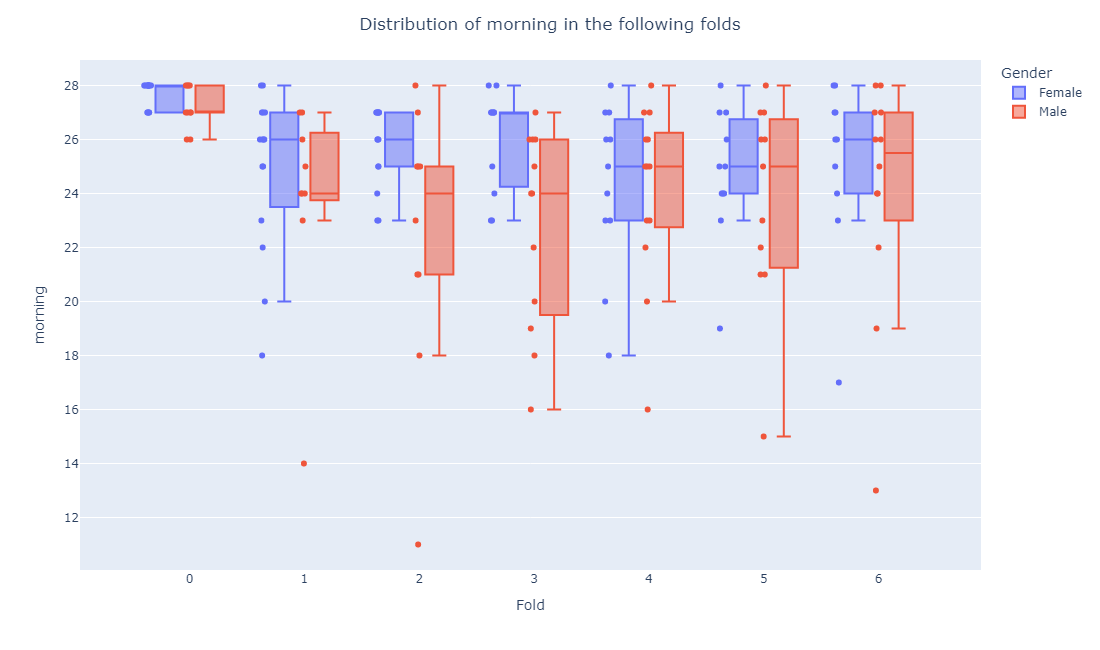

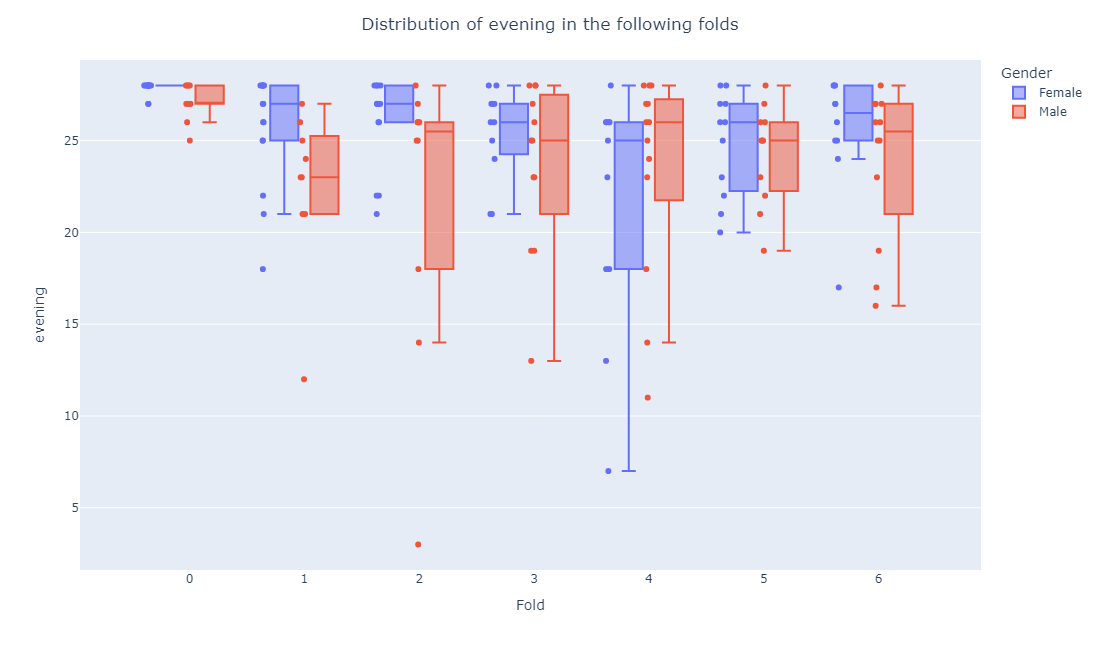

In [56]:
import plotly.express as px
import plotly.graph_objects as go

from plotly.subplots import make_subplots

tmp = result_combined_df_s[(result_combined_df_s["Gender"] == "Kobieta") | (result_combined_df_s["Gender"] == "Mężczyzna")]
tmp = tmp.replace({
    "Kobieta": "Female", "Mężczyzna": "Male",
})
for value in ["Age", "morning", "evening"]:
    fig = px.box(tmp, x="Fold", y=value, points="all", color="Gender")
    fig.update_layout(
        title_text=f"Distribution of {value} in the following folds",
        title_x=0.5,
        showlegend=True,
        autosize=True,
        width=1100,
        height=650,
    )
    fig.show("png")

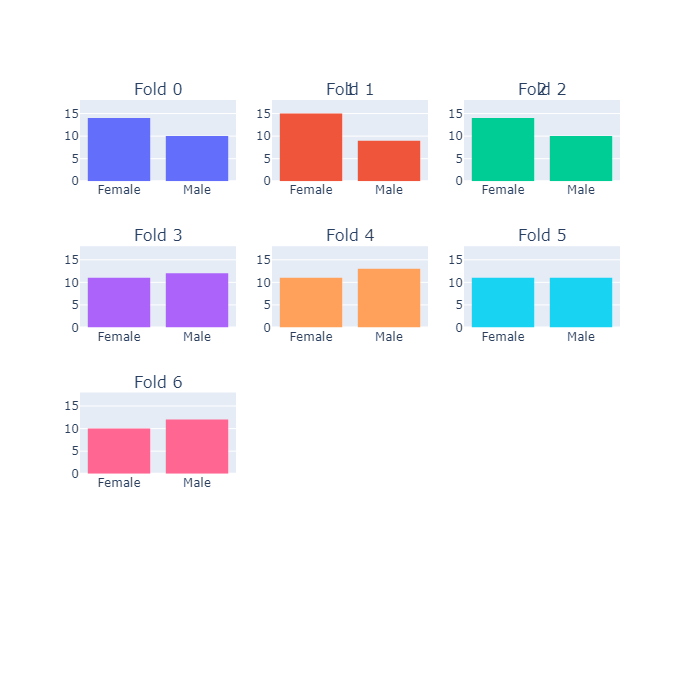

In [55]:
fig = make_subplots(rows=4, cols=3, #column_titles=list(range(8)),
                   subplot_titles=[f"Fold {x}" for x in range(7)],
                    # shared_yaxes='all'
                   )
row_num, col_num = 1, 1
for fold in range(8):
    if row_num > 2 and col_num == 2:
        break
    if col_num > 3:
        row_num += 1
        col_num = 1
    
    # print("row_num, col_num", row_num, col_num)
    f_df = result_combined_df_s[result_combined_df_s["Fold"]==fold]
    f_df = f_df.sort_values(['Gender'], ascending=[True])
    f_df = f_df.replace({
        "Kobieta": "Female", "Mężczyzna": "Male",
    })
    f_df = f_df[(f_df["Gender"] == "Female") | (f_df["Gender"] == "Male")]
    fig.add_trace(go.Histogram(x=f_df["Gender"],), row=row_num, col=col_num) #, layout_yaxis_range=[0, 15],)
    col_num += 1

fig.update_layout(
    title_text=" ",
    title_x=0.5,
    showlegend=False,
    autosize=True,
    width=700,
    height=700,
)
fig.update_yaxes(range=[0, 18])

fig.show("png")